# 04 - Baselines and honest scoring

**Why this notebook matters most.** A pretty training curve proves nothing on
its own. If random search finds the same answer just as fast, we have to say so.

We compare against:

1. **Brute force** - the exact QUBO optimum (only possible for small n).
2. **Random search** - the floor everything must beat.
3. **Greedy** - take the best stem that fits, repeat.
4. **Simulated annealing** - a strong, cheap classical optimiser.
5. **A classical GPT** - the same model, writing bitstrings directly, with no
   quantum circuit at all.

### How to run this notebook

This notebook runs on its own. You do not need the others open.

**Step 1 should have been done in notebook 01, so start from step 2 if the notebook is not yet uploaded. Also, notebooks 01, 02 and 03 are to be ran before this notebook 04.**

1. Put **gqe-rna.zip** at the top level of your Google Drive (My Drive).
   Do this once. You never need to unzip it yourself.
2. In Colab: **File -> Upload notebook** and pick this file.
3. **Runtime -> Change runtime type -> T4 GPU** (free tier is fine).
4. **Runtime -> Run all**. Approve the Drive popup when it appears.

Results are saved into `gqe-rna/results/` **in your Drive**, so they survive
when the runtime shuts down and the next notebook picks them up automatically.

If a cell says a file is missing, run the notebook it names first.

In [ ]:
# STEP 1 - Connect to Drive and find the project.
# Put gqe-rna.zip at the top level of My Drive. Do not unzip it yourself.
import sys, os, glob, subprocess, importlib

from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive"
REPO = os.path.join(ROOT, "gqe-rna")

# Unzip once, if the folder is not there yet.
if not os.path.isdir(os.path.join(REPO, "src")):
    zp = os.path.join(ROOT, "gqe-rna.zip")
    assert os.path.exists(zp), (
        "gqe-rna.zip was not found at the top level of My Drive. "
        "Upload it there (not in a subfolder), then run this cell again.")
    subprocess.run(["unzip", "-q", "-o", zp, "-d", ROOT], check=True)

# If the zip nested an extra folder, find the real one.
if not os.path.isdir(os.path.join(REPO, "src")):
    hits = glob.glob(os.path.join(ROOT, "**", "src", "colab_utils.py"),
                     recursive=True)
    assert hits, "Could not find src/ anywhere in My Drive after unzipping."
    REPO = os.path.dirname(os.path.dirname(hits[0]))

sys.path.insert(0, REPO)
importlib.invalidate_caches()   # Python cached this folder before it existed
from src import colab_utils as cu

cu.setup(repo=REPO)   # chdir into the project so results/ is saved to Drive
cu.install_vienna()

Mounted at /content/drive
project folder: /content/drive/MyDrive/gqe-rna
installing ViennaRNA ...


True

In [ ]:
# STEP 2 - Load the project code.
import numpy as np
import matplotlib.pyplot as plt
from src import rna, energy, simulator, pools, metrics, baselines

rna.set_vienna_defaults()      # pin temperature and energy model
print("ViennaRNA available:", rna.HAVE_VIENNA)
cu.show_results()              # what earlier notebooks already saved

ViennaRNA available: True
file                        size   from notebook
--------------------------------------------------
encoding.pkl                5.2K   02
gqe_model.pt             3131.0K   03
gqe_model_offline.pt     3131.4K   ?
gqe_run.pkl                19.7K   03
refs.pkl                    0.5K   01


In [ ]:
import torch
from src import gpt

saved = cu.require("refs", made_by="01")
enc = cu.require("encoding", made_by="02")
run = cu.require("gqe_run", made_by="03")

seq, stems, h, J, n = enc["seq"], enc["stems"], enc["h"], enc["J"], enc["n"]
ref_db, ref_e = saved["refs"]["challenge44"]
E = energy.full_energy_vector(h, J, dtype=energy.pick_dtype(n))
device = gpt.pick_device()
print("n =", n)

n = 22


## Give everyone the same budget

The GQE run used `epochs x n_sample` circuits, each read out with some number
of samples. We give the classical methods a comparable number of energy
evaluations so the comparison is fair.

In [ ]:
n_evals = len(run["hist"]["best"]) * 16 * 256
print("energy evaluations budget:", n_evals)

energy evaluations budget: 1024000


In [ ]:
results = {}

k, e = baselines.brute_force(E)
results['brute force (exact)'] = (energy.index_to_bits(np.array([k]), n)[0], e)

curve_rand, e_rand, i_rand = baselines.random_search(E, min(n_evals, 400000), rng=0)
results['random search'] = (energy.index_to_bits(np.array([i_rand]), n)[0], e_rand)

b, e = baselines.greedy(h, J)
results['greedy'] = (b, e)

b, e = baselines.simulated_annealing(h, J, n_steps=20000, restarts=5, rng=0)
results['simulated annealing'] = (b, e)

results['GQE (ours)'] = (energy.index_to_bits(np.array([run['best_index']]), n)[0],
                        E[run['best_index']])

## The classical ablation

Same GPT, same training idea, but it emits bitstrings instead of gates. If this
matches GQE, the quantum circuit is not contributing at this problem size.

**But happily the results show that the quantum circuit is contributing. So a GPT + quantum circuits beat a GPT alone.**

In [ ]:
curve_cgpt, e_cgpt, i_cgpt = baselines.classical_gpt_ablation(
    E, n, epochs=200, n_sample=32, device=device, seed=0)
results['classical GPT (no quantum)'] = (
    energy.index_to_bits(np.array([i_cgpt]), n)[0], e_cgpt)
print('classical GPT best QUBO energy:', round(e_cgpt, 3))

classical GPT best QUBO energy: -4.3


## Results table

`gap` is what really matters: how far the decoded structure is from the true
ViennaRNA MFE, in kcal/mol.

In [ ]:
rows = []
for name, (bits, qubo_e) in results.items():
    if bits is None:
        rows.append((name, qubo_e, None, None, None))
        continue
    db = rna.decode_bits(seq, stems, bits, h=h)
    ev = rna.eval_structure(seq, db)
    r = metrics.report(seq, db, ref_db, ev, ref_e)
    rows.append((name, qubo_e, ev, r["energy_gap"], r["f1"]))

print(f"{'method':<28} {'QUBO E':>8} {'Vienna E':>9} {'gap':>7} {'F1':>6}")
print("-"*62)
for name, q, v, g, f in rows:
    v_s = f"{v:9.2f}" if v is not None else "        -"
    g_s = f"{g:+7.2f}" if g is not None else "      -"
    f_s = f"{f:6.2f}" if f is not None else "     -"
    print(f"{name:<28} {q:8.3f} {v_s} {g_s} {f_s}")
print("-"*62)
print(f"{'ViennaRNA MFE (target)':<28} {'':>8} {ref_e:9.2f} {0.0:+7.2f} {1.0:6.2f}")

method                         QUBO E  Vienna E     gap     F1
--------------------------------------------------------------
brute force (exact)            -9.000     -7.00   +0.90   0.79
random search                   0.200      0.20   +8.10   0.00
greedy                         -3.700     -3.70   +4.20   0.67
simulated annealing            -9.000     -7.00   +0.90   0.79
GQE (ours)                     -9.000     -7.00   +0.90   0.79
classical GPT (no quantum)     -4.300     -4.30   +3.60   0.58
--------------------------------------------------------------
ViennaRNA MFE (target)                    -7.90   +0.00   1.00


It is worth noting again that we are using 22 qubits and not 27 here, in notebook 06, using 27 qubits we will get exactly -7.9 kcal/mol.

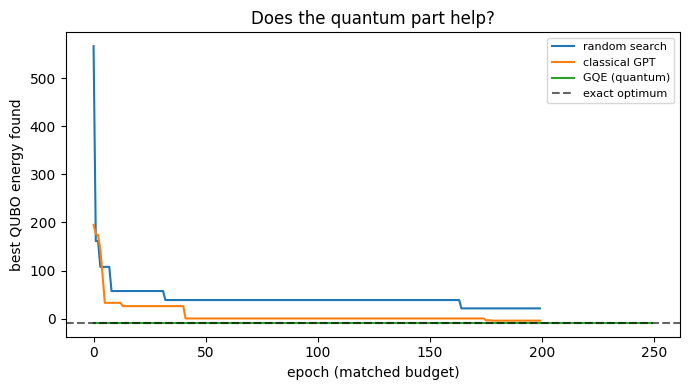

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(np.minimum.accumulate(curve_rand)[:len(curve_cgpt)*32:32],
         label="random search")
plt.plot(curve_cgpt, label="classical GPT")
plt.plot(np.array(run["hist"]["best"]), label="GQE (quantum)")
plt.axhline(E.min(), ls="--", c="k", alpha=0.6, label="exact optimum")
plt.xlabel("epoch (matched budget)"); plt.ylabel("best QUBO energy found")
plt.legend(fontsize=8); plt.title("Does the quantum part help?")
plt.tight_layout(); plt.show()

## How to read this

- If GQE reaches the exact optimum, the formulation works. Yes, the optimum using 22 quibts is -7.0 and the QGE was able to reach it.
- If random search and the classical GPT get there just as fast, then this is not right, but happily they did not. At
  n = 10 the whole space is only 1024 states, so *everything* should find it.
  That is not a failure; it means this size is too small to separate methods.
- The interesting comparison is at larger n, where the space is big enough to
  matter. Notebook 05 looks at how far we can push before the simulator dies.

In [ ]:
cu.save("baselines", {"rows": rows, "curve_cgpt": curve_cgpt})

saved results/baselines.pkl


'results/baselines.pkl'

In [ ]:
# Everything saved so far. These files live in your Drive, so the next
# notebook will find them even after this runtime shuts down.
cu.show_results()

# Uncomment to download a copy to your computer:
# cu.download_results()

file                        size   from notebook
--------------------------------------------------
baselines.pkl               2.1K   04
encoding.pkl                5.2K   02
gqe_model.pt             3131.0K   03
gqe_model_offline.pt     3131.4K   ?
gqe_run.pkl                19.7K   03
refs.pkl                    0.5K   01
